In [1]:
%load_ext autoreload
%autoreload 2

In [3]:
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits

import gausspy.gp as gp

from spectra_utils import load_spectra_from_df

In [15]:
base_dir = Path(r"/Users/javier/FLAMES_30Dor")
data_folder = "ADP_FLAMES_30Dor_30arcmin"
fits_dir = base_dir / data_folder

base_dir_test = Path(r"/Users/javier/FLAMES_30Dor/gausspy_initial_test_regular_grid")

pickle_path = base_dir / "df-regular-grid-WXY.pkl"
out_dir = base_dir_test / "gausspy_validation"
out_dir.mkdir(exist_ok=True)

print("Base directory:", base_dir)
print("FITS directory:", fits_dir)
print("Metadata pickle:", pickle_path)
print("Output directory:", out_dir)


Base directory: /Users/javier/FLAMES_30Dor
FITS directory: /Users/javier/FLAMES_30Dor/ADP_FLAMES_30Dor_30arcmin
Metadata pickle: /Users/javier/FLAMES_30Dor/df-regular-grid-WXY.pkl
Output directory: /Users/javier/FLAMES_30Dor/gausspy_initial_test_regular_grid/gausspy_validation


In [6]:
with open(pickle_path, "rb") as f:
    df_dict = pickle.load(f)

df_letter = df_dict["df_letter"]
df_expW   = df_dict["df_letterW"]
df_expX   = df_dict["df_letterX"]
df_expY   = df_dict["df_letterY"]

dfs_exp = {
    "W": df_expW,
    "X": df_expX,
    "Y": df_expY,
}

In [7]:
for key, df in dfs_exp.items():
    print(key, df.shape)



W (101, 18)
X (98, 18)
Y (71, 18)


Load spectra for W, X and Y smaples using spectra_utils

In [8]:
spectra_dict = {}

for name, df in dfs_exp.items():
    print(f"\nLoading spectra for group {name}")
    spectra_dict[name] = load_spectra_from_df(df, fits_dir)


Loading spectra for group W
Loaded 101 spectra

Loading spectra for group X
Loaded 98 spectra

Loading spectra for group Y
Loaded 71 spectra


Index: 16


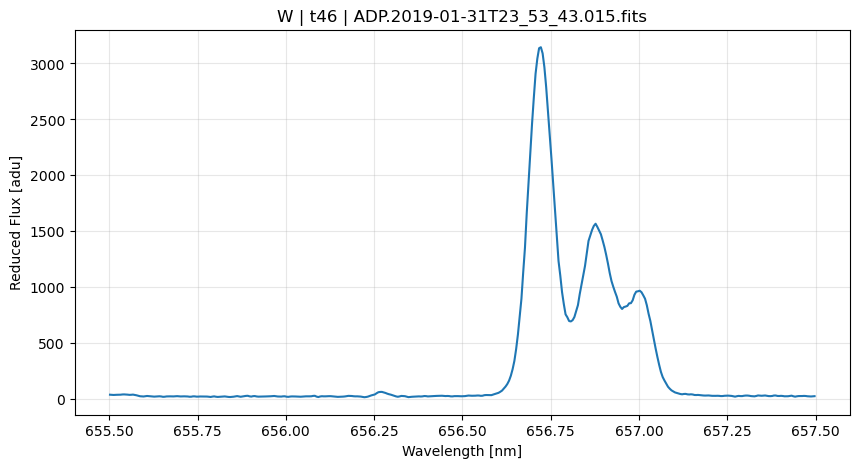

In [16]:
sample = "W"
name_object = "t46"

wmin = 655.5
wmax = 657.5

idx = next((i for i, d in enumerate(spectra_dict[sample]) if d["object"] == name_object), None)
print("Index:", idx)

if idx is not None:
    spec = spectra_dict[sample][idx]
    mask = (spec["wave"] >= wmin) & (spec["wave"] <= wmax)

    plt.figure(figsize=(10, 5))
    plt.plot(spec["wave"][mask], spec["flux"][mask])
    plt.xlabel("Wavelength [nm]")
    plt.ylabel("Reduced Flux [adu]")
    plt.title(f"{sample} | {name_object} | {spec['filename']}")
    plt.grid(alpha=0.3)
    plt.show()

In [9]:
# ============================================================
# Combine exposure dataframes from dfs_exp dictionary
# ============================================================

df_exp_all = pd.concat(
    [
        df.assign(sample=sample_name)
        for sample_name, df in dfs_exp.items()
    ],
    ignore_index=True
)

print("Rows in combined dataframe:", len(df_exp_all))
print("\nRows per sample:")
print(df_exp_all["sample"].value_counts())

display(df_exp_all.head())

Rows in combined dataframe: 270

Rows per sample:
sample
W    101
X     98
Y     71
Name: count, dtype: int64


,filename,object,date_obs,mjd_obs,instrument,telescope,arcfile,prog_id,pro_catg,dpr_catg,dpr_type,dpr_tech,ra_deg,dec_deg,EXPTIME,EXPTIME_round,sample_id,object_group,sample
0,ADP.2019-01-31T23_53_42.039.fits,u37,2003-12-03T01:44:39.244,52976.072676,GIRAFFE,ESO-VLT-U2,ADP.2019-01-31T23:53:42.039.fits,072.C-0348(A),SCIENCE_RBNSPEC_STACK,None,None,None,84.908583,-69.122194,1199.9691,1200.0,u37_ra84.908583_dec-69.122194_exp1200.0,letter_two_digits,W
1,ADP.2019-01-31T23_53_42.048.fits,t56,2003-12-03T01:44:39.244,52976.072676,GIRAFFE,ESO-VLT-U2,ADP.2019-01-31T23:53:42.048.fits,072.C-0348(A),SCIENCE_RBNSPEC_STACK,None,None,None,84.690542,-69.111083,1199.9691,1200.0,t56_ra84.690542_dec-69.111083_exp1200.0,letter_two_digits,W
2,ADP.2019-01-31T23_53_42.131.fits,u38,2003-12-03T01:44:39.244,52976.072676,GIRAFFE,ESO-VLT-U2,ADP.2019-01-31T23:53:42.131.fits,072.C-0348(A),SCIENCE_RBNSPEC_STACK,None,None,None,84.908583,-69.111083,1199.9691,1200.0,u38_ra84.908583_dec-69.111083_exp1200.0,letter_two_digits,W
3,ADP.2019-01-31T23_53_42.223.fits,t39,2003-12-03T01:44:39.244,52976.072676,GIRAFFE,ESO-VLT-U2,ADP.2019-01-31T23:53:42.223.fits,072.C-0348(A),SCIENCE_RBNSPEC_STACK,None,None,None,84.597125,-69.099972,1199.9691,1200.0,t39_ra84.597125_dec-69.099972_exp1200.0,letter_two_digits,W
4,ADP.2019-01-31T23_53_42.305.fits,u39,2003-12-03T01:44:39.244,52976.072676,GIRAFFE,ESO-VLT-U2,ADP.2019-01-31T23:53:42.305.fits,072.C-0348(A),SCIENCE_RBNSPEC_STACK,None,None,None,84.908583,-69.099972,1199.9691,1200.0,u39_ra84.908583_dec-69.099972_exp1200.0,letter_two_digits,W


Spectra for validation sample

In [10]:
spectra_validation = load_spectra_from_df(
    df_exp_all,
    fits_dir
)

Loaded 270 spectra


Inspect loaded validation spectra

In [11]:
print(type(spectra_validation))
print("Number of loaded spectra:", len(spectra_validation))

spec0 = spectra_validation[0]

print("\nType of first spectrum:")
print(type(spec0))

print("\nKeys in first spectrum:")
print(spec0.keys())

<class 'list'>
Number of loaded spectra: 270

Type of first spectrum:
<class 'dict'>

Keys in first spectrum:
dict_keys(['filename', 'object', 'ra_deg', 'dec_deg', 'wave', 'flux', 'err', 'snr'])


Build GaussPy input dictionary from loaded validation spectra

In [17]:
import numpy as np

# Wavelength window for the line region
wmin = 656
wmax = 657.5

gauss_input = {
    "data_list": [],
    "x_values": [],
    "errors": [],
    "metadata": [],
}

skipped = []

for i, spec in enumerate(spectra_validation):

    wave = np.asarray(spec["wave"], dtype=float)
    flux = np.asarray(spec["flux"], dtype=float)
    err  = np.asarray(spec["err"], dtype=float)

    # Select wavelength window
    mask = (wave >= wmin) & (wave <= wmax)

    wave_sel = wave[mask]
    flux_sel = flux[mask]
    err_sel  = err[mask]

    # Basic checks
    if len(wave_sel) == 0:
        skipped.append((i, spec["filename"], "empty wavelength window"))
        continue

    if not np.all(np.isfinite(flux_sel)):
        skipped.append((i, spec["filename"], "non-finite flux values"))
        continue

    if not np.all(np.isfinite(err_sel)):
        skipped.append((i, spec["filename"], "non-finite error values"))
        continue

    # Channel x-axis, because training was channel-based
    chan = np.arange(len(flux_sel))

    gauss_input["data_list"].append(flux_sel)
    gauss_input["x_values"].append(chan)
    gauss_input["errors"].append(err_sel)

    gauss_input["metadata"].append({
        "validation_index": i,
        "filename": spec["filename"],
        "object": spec["object"],
        "ra_deg": spec["ra_deg"],
        "dec_deg": spec["dec_deg"],
        "wave": wave_sel,
        "wmin": wmin,
        "wmax": wmax,
    })

print("Loaded validation spectra:", len(spectra_validation))
print("Prepared for GaussPy:", len(gauss_input["data_list"]))
print("Skipped:", len(skipped))

Loaded validation spectra: 270
Prepared for GaussPy: 270
Skipped: 0


Save GaussPy validation input

# GaussPy validation

In [18]:
# ============================================================
# Initialize GaussPy with trained two-phase parameters
# ============================================================

import gausspy.gp as gp

ALPHA1 = 0.90
ALPHA2 = 1.72
SNR_THRESH = [10, 10]

g = gp.GaussianDecomposer()

g.set("phase", "two")
g.set("SNR_thresh", SNR_THRESH)
g.set("alpha1", ALPHA1)
g.set("alpha2", ALPHA2)
g.set('p_width', 5)

print("GaussPy decomposer initialized.")
print("phase:", g.p["phase"])
print("SNR_thresh:", g.p["SNR_thresh"])
print("alpha1:", g.p["alpha1"])
print("alpha2:", g.p["alpha2"])
print("p_width:", g.p["p_width"])

GaussPy decomposer initialized.
phase: two
SNR_thresh: [10, 10]
alpha1: 0.9
alpha2: 1.72
p_width: 20


In [19]:
FILENAME_DATA = out_dir / "real_FLAMES_validation_input.pkl"

with open(FILENAME_DATA, "wb") as f:
    pickle.dump(gauss_input, f)

print("Saved GaussPy input file:")
print(FILENAME_DATA)
print("Exists?", FILENAME_DATA.exists())

Saved GaussPy input file:
/Users/javier/FLAMES_30Dor/gausspy_initial_test_regular_grid/gausspy_validation/real_FLAMES_validation_input.pkl
Exists? True


In [20]:
data_decomp = g.batch_decomposition(str(FILENAME_DATA))

print("Decomposition finished.")
print("Returned object type:", type(data_decomp))

using 15 out of 20 cpus
   ---->   0
   ---->      ---->     ---->  1

  0%|                                            | 0.00/269 [00:00<?, ?it/s]

   ---->     ---->     ---->      ---->      ---->     ---->     ---->     ---->  
   ---->     ---->     ---->      ---->    3 2       54 6

8791011131214
15












  0%|▏                                    | 1.00/269 [00:00<00:48, 5.50it/s]

   ---->   16
   ---->     ---->    1718   ---->  

    ---->  19 
20   ---->  
 21
   ---->      ---->  22   ---->   
 2423
   ---->     ---->     ---->  
   262527




...

   ---->   263
   ---->   264
   ---->   265   ---->  
 266
   ---->     ---->    268267



 94%|███████████████████████████████████▉  | 254/269 [00:04<00:00, 53.5it/s]

   ---->   269


100%|██████████████████████████████████████| 269/269 [00:05<00:00, 49.7it/s]
269it [00:00, 701659.06it/s]

SUCCESS
100 finished.%
Decomposition finished.
Returned object type: <class 'dict'>


Save decomposition result

In [21]:
FILENAME_DATA_DECOMP = out_dir / "real_FLAMES_validation_decomposed.pkl"

with open(FILENAME_DATA_DECOMP, "wb") as f:
    pickle.dump(data_decomp, f)

print("Saved decomposition:")
print(FILENAME_DATA_DECOMP)

Saved decomposition:
/Users/javier/FLAMES_30Dor/gausspy_initial_test_regular_grid/gausspy_validation/real_FLAMES_validation_decomposed.pkl


Inspect GaussPy decomposition output

In [22]:
print("Returned object type:", type(data_decomp))

if isinstance(data_decomp, dict):
    print("\nTop-level keys:")
    for key in data_decomp.keys():
        print(" -", key)

elif isinstance(data_decomp, list):
    print("\nList length:", len(data_decomp))
    for i, item in enumerate(data_decomp):
        print(f"Element {i}: {type(item)}")

else:
    print("\nObject representation:")
    print(data_decomp)

Returned object type: <class 'dict'>

Top-level keys:
 - index_fit
 - amplitudes_fit
 - fwhms_fit
 - means_fit
 - index_initial
 - amplitudes_initial
 - fwhms_initial
 - means_initial
 - amplitudes_fit_err
 - fwhms_fit_err
 - means_fit_err
 - best_fit_rchi2
 - amplitudes_fit_em
 - fwhms_fit_em
 - means_fit_em
 - means_fit_err_em
 - amplitudes_fit_err_em
 - fwhms_fit_err_em
 - fit_labels


In [23]:
n_input = len(gauss_input["data_list"])
n_output = len(data_decomp["means_fit"])

print("Number of input spectra:", n_input)
print("Number of decomposed spectra:", n_output)

print("\nSame number?")
print(n_input == n_output)

Number of input spectra: 270
Number of decomposed spectra: 270

Same number?
True


In [24]:
# ============================================================
# Inspect first decomposition result
# ============================================================

i = 0

print("Spectrum index:", i)
print("Filename:", gauss_input["metadata"][i]["filename"])
print("Object:", gauss_input["metadata"][i]["object"])

print("\nInitial components:")
print("means_initial:", data_decomp["means_initial"][i])
print("fwhms_initial:", data_decomp["fwhms_initial"][i])
print("amps_initial :", data_decomp["amplitudes_initial"][i])

print("\nFitted components:")
print("means_fit:", data_decomp["means_fit"][i])
print("fwhms_fit:", data_decomp["fwhms_fit"][i])
print("amps_fit :", data_decomp["amplitudes_fit"][i])

print("\nReduced chi-square:")
print(data_decomp["best_fit_rchi2"][i])

Spectrum index: 0
Filename: ADP.2019-01-31T23_53_42.039.fits
Object: u37

Initial components:
means_initial: [182.5 183.5 136.5 138.5  53.5]
fwhms_initial: [25.76748819 26.70029612 32.33472124 25.47619838 20.71772598]
amps_initial : [1389.40365004  497.24581824  147.90267458  104.1268135    49.64507288]

Fitted components:
means_fit: [181.77575923788163, 198.49787194221318, 175.76392761005997, 136.56644397118504, 45.12410989409729]
fwhms_fit: [17.3432447483513, 178.63906529393242, 42.51159893805462, 13.33389599703806, 69.99883606362937]
amps_fit : [832.2357969057612, 24.91184849357537, 561.1703574653283, 89.44719474047183, 15.196303753481175]

Reduced chi-square:
[2.908704257300778]


In [25]:
import numpy as np
import matplotlib.pyplot as plt

def gaussian(amp, fwhm, mean):
    return lambda x: amp * np.exp(-4.0 * np.log(2) * (x - mean)**2 / fwhm**2)

In [26]:
PLOT_INDEX = 25

In [27]:
spectrum = np.asarray(gauss_input["data_list"][PLOT_INDEX], dtype=float)
chan     = np.asarray(gauss_input["x_values"][PLOT_INDEX], dtype=float)
errors   = np.asarray(gauss_input["errors"][PLOT_INDEX], dtype=float)

means_fit = np.asarray(data_decomp["means_fit"][PLOT_INDEX], dtype=float)
amps_fit  = np.asarray(data_decomp["amplitudes_fit"][PLOT_INDEX], dtype=float)
fwhms_fit = np.asarray(data_decomp["fwhms_fit"][PLOT_INDEX], dtype=float)

print("Filename:", gauss_input["metadata"][PLOT_INDEX]["filename"])
print("Object:", gauss_input["metadata"][PLOT_INDEX]["object"])
print("Number of fitted components:", len(means_fit))

Filename: ADP.2019-01-31T23_53_43.711.fits
Object: t18
Number of fitted components: 4


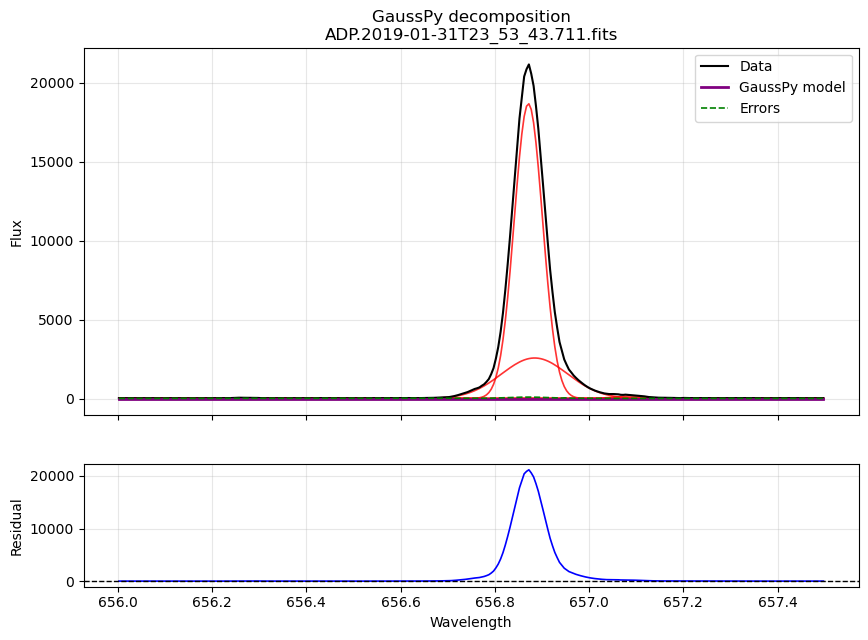

In [28]:
wave = np.asarray(gauss_input["metadata"][PLOT_INDEX]["wave"], dtype=float)

model = np.zeros(len(chan))
residuals = spectrum - model

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(10, 7), sharex=True,
    gridspec_kw={"height_ratios": [3, 1]}
)

# Top panel
for j in range(len(means_fit)):
    component = gaussian(amps_fit[j], fwhms_fit[j], means_fit[j])(chan)
    ax1.plot(wave, component, color="red", lw=1.2, alpha=0.8)

ax1.plot(wave, spectrum, label="Data", color="black", linewidth=1.5)
ax1.plot(wave, model, label="GaussPy model", color="purple", linewidth=2.0)
ax1.plot(wave, errors, label="Errors", color="green", linestyle="dashed", linewidth=1.2)

ax1.set_ylabel("Flux")
ax1.set_title(
    f"GaussPy decomposition\n"
    f"{gauss_input['metadata'][PLOT_INDEX]['filename']}"
)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Bottom panel
ax2.plot(wave, residuals, color="blue", linewidth=1.2)
ax2.axhline(0, color="black", linestyle="--", linewidth=1.0)
ax2.set_xlabel("Wavelength")
ax2.set_ylabel("Residual")
ax2.grid(True, alpha=0.3)

plt.show()

In [36]:
import numpy as np
import matplotlib.pyplot as plt


def gaussian_model(x, amp, fwhm, mean):
    """
    Gaussian parameterized by amplitude, FWHM, and mean.

    Parameters
    ----------
    x : ndarray
        Coordinate array. In our GaussPy validation this is channel number.

    amp : float
        Gaussian amplitude.

    fwhm : float
        Full width at half maximum, in the same units as x.

    mean : float
        Gaussian center, in the same units as x.

    Returns
    -------
    y : ndarray
        Gaussian evaluated at x.
    """
    return amp * np.exp(-4.0 * np.log(2.0) * (x - mean)**2 / fwhm**2)


def plot_gausspy_fit(
    gauss_input,
    data_decomp,
    plot_index=0,
    use_wavelength=True,
    show_errors=True,
    show_components=True,
    figsize=(10, 7),
    show=True,
):
    """
    Plot one GaussPy decomposition result for a validation spectrum.

    Parameters
    ----------
    gauss_input : dict
        Input dictionary used by GaussPy. It must contain:
        'data_list', 'x_values', 'errors', and 'metadata'.

    data_decomp : dict
        Output dictionary returned by GaussPy batch_decomposition.
        It must contain:
        'means_fit', 'amplitudes_fit', 'fwhms_fit'.

    plot_index : int, default=0
        Index of the validation spectrum to plot.

    use_wavelength : bool, default=True
        If True, plot against wavelength using metadata['wave'].
        If False, plot against channel number.

    show_errors : bool, default=True
        If True, plot the error array.

    show_components : bool, default=True
        If True, plot individual Gaussian components.

    figsize : tuple, default=(10, 7)
        Figure size.

    Returns
    -------
    fig, axes : matplotlib Figure and Axes
        Figure and axes objects.
    """

    # --------------------------
    # Extract input spectrum
    # --------------------------
    spectrum = np.asarray(gauss_input["data_list"][plot_index], dtype=float)
    chan = np.asarray(gauss_input["x_values"][plot_index], dtype=float)
    errors = np.asarray(gauss_input["errors"][plot_index], dtype=float)

    metadata = gauss_input["metadata"][plot_index]

    # --------------------------
    # Extract fitted parameters
    # --------------------------
    means_fit = np.asarray(data_decomp["means_fit"][plot_index], dtype=float)
    amps_fit = np.asarray(data_decomp["amplitudes_fit"][plot_index], dtype=float)
    fwhms_fit = np.asarray(data_decomp["fwhms_fit"][plot_index], dtype=float)

    # --------------------------
    # Build total model
    # --------------------------
    model = np.zeros_like(spectrum, dtype=float)

    components = []

    for amp, fwhm, mean in zip(amps_fit, fwhms_fit, means_fit):
        component = gaussian_model(chan, amp, fwhm, mean)
        components.append(component)
        model += component

    residuals = spectrum - model

    # --------------------------
    # Choose x-axis for plotting
    # --------------------------
    if use_wavelength:
        x_plot = np.asarray(metadata["wave"], dtype=float)
        x_label = "Wavelength"
    else:
        x_plot = chan
        x_label = "Channel"

    # --------------------------
    # Metadata for title
    # --------------------------
    filename = metadata.get("filename", "unknown filename")
    obj = metadata.get("object", "unknown object")

    rchi2 = data_decomp.get("best_fit_rchi2", [None] * len(gauss_input["data_list"]))[plot_index]

    # --------------------------
    # Plot
    # --------------------------
    fig, (ax1, ax2) = plt.subplots(
        2,
        1,
        figsize=figsize,
        sharex=True,
        gridspec_kw={"height_ratios": [3, 1]},
    )

    if show_components:
        for component in components:
            ax1.plot(
                x_plot,
                component,
                color="red",
                lw=1.2,
                alpha=0.8,
            )

    ax1.plot(
        x_plot,
        spectrum,
        label="Data",
        color="black",
        linewidth=1.5,
    )

    ax1.plot(
        x_plot,
        model,
        label="GaussPy model",
        color="purple",
        linewidth=2.0,
    )

    if show_errors:
        ax1.plot(
            x_plot,
            errors,
            label="Errors",
            color="green",
            linestyle="dashed",
            linewidth=1.2,
            alpha=0.8,
        )

    ax1.set_ylabel("Flux")
    ax1.set_title(
        f"GaussPy decomposition | index {plot_index}\n"
        f"{obj} | {filename}\n"
        f"ncomp = {len(means_fit)}, rchi2 = {rchi2}"
    )
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(
        x_plot,
        residuals,
        color="blue",
        linewidth=1.2,
    )
    ax2.axhline(
        0,
        color="black",
        linestyle="--",
        linewidth=1.0,
    )

    ax2.set_xlabel(x_label)
    ax2.set_ylabel("Residual")
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    
    if show:
        plt.show()

    return fig, (ax1, ax2)

(<Figure size 1000x700 with 2 Axes>,
 (<Axes: title={'center': 'GaussPy decomposition | index 5\nt37 | ADP.2019-01-31T23_53_42.319.fits\nncomp = 3, rchi2 = [5.731427347247692]'}, ylabel='Flux'>,
  <Axes: xlabel='Wavelength', ylabel='Residual'>))

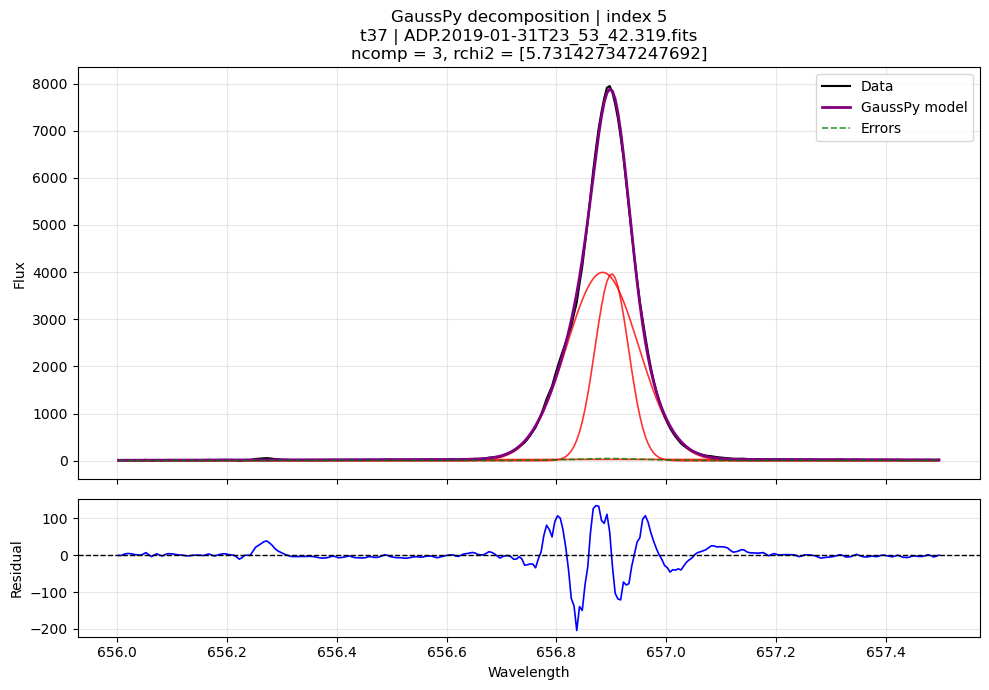

In [37]:
plot_gausspy_fit(
    gauss_input,
    data_decomp,
    plot_index=5,
    use_wavelength=True,
    show = False
)

In [39]:
from pathlib import Path
import re
import matplotlib.pyplot as plt

# ============================================================
# Output folder for saved plots
# ============================================================

save_dir = Path("/Users/javier/FLAMES_30dor/gausspy_initial_test_regular_grid/gausspy_validation/plots_validation")
save_dir.mkdir(parents=True, exist_ok=True)

# ============================================================
# Helper to make safe filenames
# ============================================================

def safe_string(text):
    """
    Convert text into a safe filename.
    """
    text = str(text)
    text = re.sub(r"[^\w\-_.]", "_", text)
    return text

# ============================================================
# Loop over all validation spectra and save plots
# ============================================================

n_spectra = len(gauss_input["data_list"])

print(f"Saving plots for {n_spectra} spectra...")
print(f"Output folder: {save_dir}")

for i in range(n_spectra):
    metadata = gauss_input["metadata"][i]

    filename = metadata.get("filename", f"spectrum_{i}")
    obj = metadata.get("object", f"obj_{i}")

    filename_safe = safe_string(filename)
    obj_safe = safe_string(obj)

    save_path = save_dir / f"{i:02d}_{obj_safe}_{filename_safe}.png"

    fig, axes = plot_gausspy_fit(
        gauss_input,
        data_decomp,
        plot_index=i,
        use_wavelength=True,     # change to False if you prefer channels
        show_errors=True,
        show_components=True,
        figsize=(10, 7),
        show = False,
    )

    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close(fig)

    print(f"Saved: {save_path.name}")

print("Done.")

Saving plots for 270 spectra...
Output folder: /Users/javier/FLAMES_30dor/gausspy_initial_test_regular_grid/gausspy_validation/plots_validation
Saved: 00_u37_ADP.2019-01-31T23_53_42.039.fits.png
Saved: 01_t56_ADP.2019-01-31T23_53_42.048.fits.png
Saved: 02_u38_ADP.2019-01-31T23_53_42.131.fits.png
Saved: 03_t39_ADP.2019-01-31T23_53_42.223.fits.png
Saved: 04_u39_ADP.2019-01-31T23_53_42.305.fits.png
Saved: 05_t37_ADP.2019-01-31T23_53_42.319.fits.png
Saved: 06_t22_ADP.2019-01-31T23_53_42.328.fits.png
Saved: 07_u13_ADP.2019-01-31T23_53_42.356.fits.png
Saved: 08_t54_ADP.2019-01-31T23_53_42.423.fits.png
Saved: 09_u44_ADP.2019-01-31T23_53_42.427.fits.png
Saved: 10_t29_ADP.2019-01-31T23_53_42.483.fits.png
Saved: 11_t34_ADP.2019-01-31T23_53_42.509.fits.png
Saved: 12_u04_ADP.2019-01-31T23_53_42.684.fits.png
Saved: 13_t27_ADP.2019-01-31T23_53_42.740.fits.png
Saved: 14_t10_ADP.2019-01-31T23_53_42.777.fits.png
Saved: 15_t09_ADP.2019-01-31T23_53_42.944.fits.png
Saved: 16_t46_ADP.2019-01-31T23_53_43.01

In [40]:
out_dir

PosixPath('/Users/javier/FLAMES_30Dor/gausspy_initial_test_regular_grid/gausspy_validation')

In [42]:
from pathlib import Path
import pickle

#out_dir = Path("/Users/javier/FLAMES_30dor/gausspy_validation")

FILENAME_DATA = out_dir / "real_FLAMES_validation_input.pkl"
FILENAME_DATA_DECOMP = out_dir / "real_FLAMES_validation_decomposed.pkl"

print("Input file exists?")
print(FILENAME_DATA.exists(), FILENAME_DATA)

print("\nDecomposition file exists?")
print(FILENAME_DATA_DECOMP.exists(), FILENAME_DATA_DECOMP)

Input file exists?
True /Users/javier/FLAMES_30Dor/gausspy_initial_test_regular_grid/gausspy_validation/real_FLAMES_validation_input.pkl

Decomposition file exists?
True /Users/javier/FLAMES_30Dor/gausspy_initial_test_regular_grid/gausspy_validation/real_FLAMES_validation_decomposed.pkl


In [45]:
df_validation = df_exp_all

ILENAME_DF_VALIDATION = out_dir / "df_validation.pkl"

with open(FILENAME_DF_VALIDATION, "wb") as f:
    pickle.dump(df_validation, f)

print("Saved validation dataframe:")
print(FILENAME_DF_VALIDATION)
print("Exists?", FILENAME_DF_VALIDATION.exists())

Saved validation dataframe:
/Users/javier/FLAMES_30Dor/gausspy_initial_test_regular_grid/gausspy_validation/df_validation.pkl
Exists? True


In [44]:
# ============================================================
# Save validation configuration
# ============================================================

training_config = {
    "phase": "two",
    "alpha1": 0.90,
    "alpha2": 1.72,
    "SNR_thresh": [10, 10],
    "input_file": str(FILENAME_DATA),
    "decomposition_file": str(FILENAME_DATA_DECOMP),
    "notes": "FLAMES 30 Dor validation sample using trained GaussPy two-phase parameters.",
}

FILENAME_CONFIG = out_dir / "validation_training_config.pkl"

with open(FILENAME_CONFIG, "wb") as f:
    pickle.dump(training_config, f)

print("Saved validation config:")
print(FILENAME_CONFIG)
print("Exists?", FILENAME_CONFIG.exists())

Saved validation config:
/Users/javier/FLAMES_30Dor/gausspy_initial_test_regular_grid/gausspy_validation/validation_training_config.pkl
Exists? True
